## Asignatura: Seminario Avanzado de Aprendizaje Automático 2025-2026
## **Entregable Parte 3**
#### Master en Lógica, Computación e Inteligencia Artificial
#### Profesor: Eduardo Sánchez Karhunen (fesanchez at us.es)


#### Nombre del alumno/a:

Jose Sanz

# **Desafío: Tu Primer Clasificador con BERT**

Ahora que ya conoces los fundamentos de los modelos Transformer y las arquitecturas BERT/GPT, ha llegado el momento de aplicar ese conocimiento. Te propongo un reto abierto y creativo. Vamos a hacer algo muy parecido a lo que te podría tocar en tu primer día trabajando en una empresa de IA. Te encargan una tarea sin darte muchas pistas, y tú tienes que organizarte y sacarla adelante. No te preocupes: aquí tendrás más tiempo que en la vida real 😉. En el mundo real te darían una mañana para hacer esto. Aquí vas a tener 10 días. ¡Úsalos bien!

El objetivo no es pasarlo mal, sino que te enfrentes a un reto realista. La idea es que veas la diferencia tan grande que hay entre tener un notebook con el código ya escrito y la infinidad de dificultades que aparecen cuando tienes que montarlo tú mismo desde cero.

**Pista importante:**

La explicación de lo que haces importa casi tanto como lo que haces. En cada paso debes ir explicando:

* Qué pasos has seguido

* Dónde has buscado información

* Qué te ha costado más

* Cómo lo has solucionado

El objetivo es que seas capaz de entrenar y evaluar el modelo. Pero tanto si lo consigues como si no, en el entregable explicalo TODO (incluido los motivos por los que no has sido capaz de completarlo, las dificultades que te has encontrado, etc.).

Pero recuerda que lo más importante es lo que te lleves en tu "mochila" trabajando el notebook y eso es lo que se va a evaluar. Todo eso queda plasmado en la mítica escena de Star Wars donde el Maestro Yoda le dice a SkyWalker: **"El fracaso, el mejor maestro es"**.  

**¿Qué tienes que hacer?**

Escoge **el dataset que quieras** (siempre que sea de procesamiento del lenguaje natural) y **resuelve un problema de clasificación** con él (por ejemplo, clasificar opiniones, intenciones, temas, etc.)

Pero hay una condición:

**Tienes que usar embeddings generados por un modelo tipo BERT.**

Además no vale solo que funcione:

**Tienes que justificar las decisiones** que tomes. Piensa como si tuvieras que explicarle tu solución a tu jefe o a tu cliente.

## 🧪 **Tarea 1: ¡Tu eliges la aventura!**

Es el momento de ponerte en el lugar de un data scientist de verdad. Elige el dataset que más te guste y plantea un problema de clasificación con el.

Para ello, describe:

* Cual es el problema de clasificación que vas a resolver.

     *Tu explicación aquí*

* Qué dataset has elegido y por qué.

     *Tu explicación aquí*

#### Mi respuesta a la Tarea 1

**Qué problema de clasificación voy a resolver**

He decidido montar un clasificador de emociones a partir de texto. La idea, contada de forma sencilla, es: dado un mensaje corto escrito por una persona (por ejemplo un tuit), quiero que el modelo diga qué emoción principal expresa. Es un problema de clasificación multiclase con 6 categorías posibles: alegría (joy), tristeza (sadness), ira (anger), miedo (fear), amor (love) y sorpresa (surprise).

Me parece un problema realista y con sentido: algo parecido se usa para analizar opiniones en redes sociales, medir cómo reacciona la gente ante una noticia o un producto, o para ordenar mensajes de atención al cliente según el tono. Además, al tener 6 clases y no un simple positivo/negativo, da más juego después para analizar dónde acierta y dónde falla el modelo.

**Qué dataset he elegido y por qué**

He elegido el dataset `emotion` (en Hugging Face aparece como `dair-ai/emotion`). Llegué a él buscando datasets de clasificación de texto en el Hub de Hugging Face (https://huggingface.co/datasets), que fue lo primero que miré porque estos datasets se integran muy fácil con la librería `datasets` y con los modelos tipo BERT que vimos en clase.

Razones por las que me encaja bien:

- Es un problema de NLP de clasificación, que es justo lo que pide el enunciado.
- Ya viene dividido en train, validación y test. Esto me viene de cara para la Tarea 3, donde se dice que si el dataset ya trae su propia división, hay que usarla.
- Los textos son cortos (mensajes tipo tuit). Esto es importante porque voy a trabajar en mi portátil con CPU: cuanto más cortos los textos, más rápido los tokeniza y procesa BERT, y menos me afecta tener que recortar frases largas.
- Está en inglés, así que puedo usar `bert-base-uncased`, que es el mismo modelo que usamos en la práctica de clase (Session 1). Prefiero apoyarme en algo que ya entiendo antes que meterme con un modelo nuevo.
- Tiene las clases desbalanceadas y algunas emociones que se parecen entre sí (por ejemplo alegría y amor, o miedo y sorpresa). Esto, que en principio puede sonar a inconveniente, en realidad me viene muy bien para las Tareas 2 y 6: podré comentar el desbalanceo y mirar en la matriz de confusión qué emociones acaba confundiendo el modelo.

**Otras opciones que valoré antes de decidirme**

- AG News (clasificar noticias en 4 temas: mundo, deportes, negocios y ciencia/tecnología): es muy limpio y está balanceado, pero me parecía menos interesante para analizar errores, porque los temas se distinguen bastante bien y casi no se confunden.
- Un dataset en español con un BERT en español (BETO): era la opción que más me apetecía por estar en mi idioma, pero suponía cambiar de modelo respecto a la práctica y, según el dataset, complicarme más el montaje. Lo dejo anotado como una posible mejora para más adelante; primero quiero tener todo el pipeline funcionando de principio a fin.

Al final me quedé con `emotion` porque es el equilibrio que buscaba: un problema realista, manejable en CPU y con suficiente riqueza para poder explicar bien los resultados.

## 🕵️‍♂️ **Tarea 2: Conociendo tus datos**

Antes de hacer magia con BERT, ¡hay que conocer los datos! Haz un pequeño análisis exploratorio: cuántos ejemplos hay, cómo están distribuidas las clases, qué pinta tienen los textos ...

***Tip***: No hace falta que sea un extremadamente técnico, pero intenta entender qué tienes delante.

In [1]:
# Tu código y explicación aquí

#### Mi enfoque para la Tarea 2

Antes de tocar BERT quiero entender bien qué datos tengo entre manos. Me voy a fijar en cuatro cosas sencillas pero importantes:

1. Cuántos ejemplos hay en cada partición (train, validación y test).
2. Cómo están repartidas las 6 clases, para ver si el dataset está equilibrado o no.
3. Qué longitud tienen los textos (en palabras), porque eso me ayudará luego a elegir el `max_length` cuando tokenice.
4. Qué pinta tienen algunos textos de verdad, leyendo ejemplos de cada emoción.

Cargo los datos con la librería `datasets` de Hugging Face, que se encarga de descargar el dataset y dejarlo listo para usar. Para esta parte todavía no necesito TensorFlow: solo quiero mirar los datos.

In [2]:
# Configuracion para que la salida quede limpia (silenciar avisos no criticos).
import os
import warnings
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"   # aviso de symlinks en Windows
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"               # menos mensajes de TensorFlow
warnings.filterwarnings("ignore")

# Librerias para explorar los datos (todavia no hace falta TensorFlow).
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

# Fijo una semilla para que los resultados sean reproducibles.
SEMILLA = 42
np.random.seed(SEMILLA)

# Cargo el dataset 'emotion'. Pruebo varias formas por si cambia el identificador o la config.
dataset = None
for argumentos in [("dair-ai/emotion",), ("dair-ai/emotion", "split"), ("emotion",)]:
    try:
        dataset = load_dataset(*argumentos)
        print("Dataset cargado con:", argumentos)
        break
    except Exception as e:
        print("No se pudo cargar con", argumentos, "->", repr(e)[:120])

# Nombres de las clases (en el mismo orden que los indices 0..5).
nombres_clases = dataset["train"].features["label"].names

print()
print("Particiones y numero de ejemplos:")
for particion, datos in dataset.items():
    print(f"  {particion:12s}: {len(datos)} ejemplos")

print()
print("Clases (indice -> nombre):")
for i, nombre in enumerate(nombres_clases):
    print(f"  {i} -> {nombre}")

# Paso cada particion a un DataFrame de pandas, que para explorar es mas comodo.
df_train = dataset["train"].to_pandas()
df_val = dataset["validation"].to_pandas()
df_test = dataset["test"].to_pandas()

# Anado una columna con el nombre de la emocion (ademas del indice) para que se lea mejor.
for df in (df_train, df_val, df_test):
    df["emocion"] = df["label"].map(lambda i: nombres_clases[i])

print()
print("Primeras filas del train:")
df_train.head()

Dataset cargado con: ('dair-ai/emotion',)

Particiones y numero de ejemplos:
  train       : 16000 ejemplos
  validation  : 2000 ejemplos
  test        : 2000 ejemplos

Clases (indice -> nombre):
  0 -> sadness
  1 -> joy
  2 -> love
  3 -> anger
  4 -> fear
  5 -> surprise

Primeras filas del train:


,text,label,emocion
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger


Lo primero que miro es **cómo están repartidas las clases** en el conjunto de train. Esto es importante porque si una emoción tiene muchísimos más ejemplos que otra (dataset desbalanceado), el modelo tenderá a predecir las clases mayoritarias y le costará las raras. Saberlo ahora me sirve para luego interpretar bien los resultados.

Distribucion de clases en train:
  joy       :  5362  (33.5 %)
  sadness   :  4666  (29.2 %)
  anger     :  2159  (13.5 %)
  fear      :  1937  (12.1 %)
  love      :  1304  (8.2 %)
  surprise  :   572  (3.6 %)


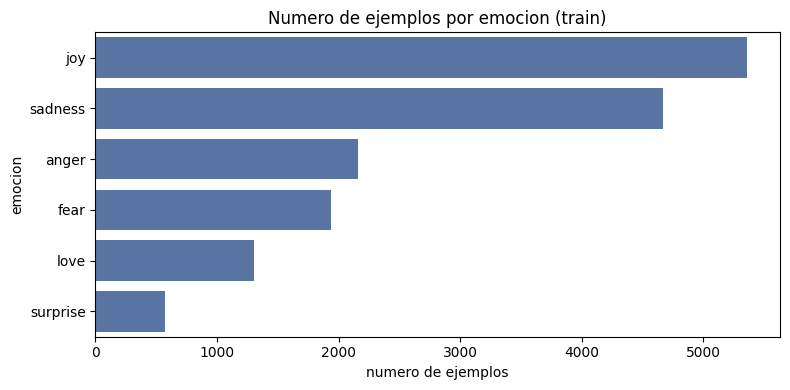

In [3]:
# Cuento cuantos ejemplos hay de cada emocion en train y lo paso a porcentaje.
conteo = df_train["emocion"].value_counts()
porcentaje = (conteo / len(df_train) * 100).round(1)

print("Distribucion de clases en train:")
for emocion in conteo.index:
    print(f"  {emocion:10s}: {conteo[emocion]:5d}  ({porcentaje[emocion]} %)")

# Lo dibujo en un grafico de barras para verlo de un vistazo.
plt.figure(figsize=(8, 4))
sns.barplot(x=conteo.values, y=conteo.index, color="#4C72B0")
plt.title("Numero de ejemplos por emocion (train)")
plt.xlabel("numero de ejemplos")
plt.ylabel("emocion")
plt.tight_layout()
plt.show()

Ahora miro la **longitud de los textos**, contando palabras (separando por espacios). Es una aproximación: BERT no trabaja con palabras sino con *tokens* de WordPiece, que parten algunas palabras en trozos, así que el número real de tokens será algo mayor. Pero para hacerme una idea del tamaño me vale, y me ayudará a decidir el `max_length` en la Tarea 4 (un valor que cubra casi todos los textos sin desperdiciar memoria).

Estadisticas de longitud (en palabras) en train:
count    16000.0
mean        19.2
std         11.0
min          2.0
25%         11.0
50%         17.0
75%         25.0
max         66.0
Name: n_palabras, dtype: float64

Percentil 95: 41 palabras
Percentil 99: 52 palabras
Maximo: 66 palabras


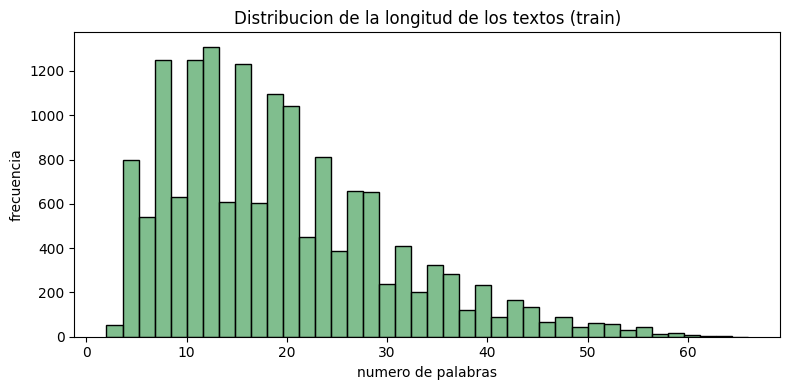

In [4]:
# Longitud de cada texto en numero de palabras.
df_train["n_palabras"] = df_train["text"].str.split().str.len()

print("Estadisticas de longitud (en palabras) en train:")
print(df_train["n_palabras"].describe().round(1))
print()
print("Percentil 95:", int(np.percentile(df_train["n_palabras"], 95)), "palabras")
print("Percentil 99:", int(np.percentile(df_train["n_palabras"], 99)), "palabras")
print("Maximo:", int(df_train["n_palabras"].max()), "palabras")

plt.figure(figsize=(8, 4))
sns.histplot(df_train["n_palabras"], bins=40, color="#55A868")
plt.title("Distribucion de la longitud de los textos (train)")
plt.xlabel("numero de palabras")
plt.ylabel("frecuencia")
plt.tight_layout()
plt.show()

Por último, leo **algunos ejemplos reales de cada emoción**. Mirar los textos de verdad ayuda a entender el problema: ver si son frases en primera persona, si el vocabulario delata la emoción, y si hay casos que a mí mismo me costaría clasificar (lo que adelanta que al modelo también le costarán).

In [5]:
# Muestro 2 ejemplos de cada emocion para ver que pinta tienen los textos.
for emocion in nombres_clases:
    ejemplos = df_train[df_train["emocion"] == emocion]["text"].head(2).tolist()
    print(f"--- {emocion} ---")
    for t in ejemplos:
        print("  ", t)
    print()

--- sadness ---
   i didnt feel humiliated
   i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake

--- joy ---
   i have been with petronas for years i feel that petronas has performed well and made a huge profit
   i do feel that running is a divine experience and that i can expect to have some type of spiritual encounter

--- love ---
   i am ever feeling nostalgic about the fireplace i will know that it is still on the property
   i feel romantic too

--- anger ---
   im grabbing a minute to post i feel greedy wrong
   i am feeling grouchy

--- fear ---
   i feel as confused about life as a teenager or as jaded as a year old man
   i now feel compromised and skeptical of the value of every unit of work i put in

--- surprise ---
   ive been taking or milligrams or times recommended amount and ive fallen asleep a lot faster but i also feel like so funny
   i have seen heard and read over the past couple of days i am left feelin

#### Qué he aprendido mirando los datos

Después de explorar un poco, estas son mis conclusiones:

**Tamaño y división.** El dataset trae 16000 ejemplos para entrenar, 2000 para validación y 2000 para test. Como ya viene dividido, en la Tarea 3 usaré esta misma división en lugar de inventarme yo el reparto.

**Las clases están muy desbalanceadas.** No todas las emociones aparecen igual de veces:

- joy (alegría): 33,5 %
- sadness (tristeza): 29,2 %
- anger (ira): 13,5 %
- fear (miedo): 12,1 %
- love (amor): 8,2 %
- surprise (sorpresa): 3,6 %

Entre alegría y tristeza se llevan más del 60 % de los ejemplos, mientras que sorpresa apenas tiene un 3,6 %. Esto conviene tenerlo presente: si luego el modelo acierta mucho de media pero falla en sorpresa, será bastante normal, porque ha visto poquísimos ejemplos de esa clase. Por eso en la evaluación (Tarea 6) no me fijaré solo en el accuracy global, sino también en las métricas por clase y en la matriz de confusión. Además me sirve de referencia que un modelo "tonto" que prediga siempre la clase mayoritaria (joy) ya acertaría un 33,5 %, así que el mío tiene que superar claramente ese listón para que valga la pena.

**Los textos son cortos.** En palabras: de media 19, la mitad tienen 17 o menos, el percentil 95 está en 41 y el más largo tiene 66. Esto me viene muy bien para trabajar en CPU. Como BERT no parte por palabras sino en tokens de WordPiece (que suelen salir algunos más que las palabras), el número real de tokens será un poco mayor, pero aun así con un max_length de unos 64 tokens cubriría casi todos los textos sin cortar casi nada. Lo afinaré en la Tarea 4, pero ya tengo una buena referencia.

**Qué pinta tienen.** Casi todos los textos son frases en primera persona que incluyen la palabra "feel" ("i feel...", "i am feeling..."). Tiene sentido, porque el dataset se construyó a partir de mensajes donde la gente cuenta cómo se siente. Leyendo los ejemplos, algunos se entienden enseguida (por ejemplo "i feel romantic too" para love), pero otros son ambiguos incluso para mí (los de surprise no me parecen nada claros). Eso ya me avisa de que habrá clases que al modelo le van a costar más, sobre todo las que tienen pocos ejemplos y se solapan con otras.

## ✂️ **Tarea 3: ¡Divide y vencerás!**

Separa los datos en train y test. Por ahora, olvídate de tensores y frameworks raros: con `numpy` vas más rápido y te evitas líos.

* ¿El dataset ya venía dividido? Usa esa división.
* En caso contrario, usa un 80% para train y un 20% para test.

Quieres que las **clases estén bien representadas** en ambos conjuntos, así que utiliza el argumento `stratify = y` de scikit-learn.

In [6]:
# Tu código y explicación aquí

#### Mi enfoque para la Tarea 3

El enunciado dice que, si el dataset ya viene dividido, use esa división. Y este es el caso: `emotion` ya trae sus particiones de train, validación y test. Así que no voy a usar `train_test_split` ni a inventarme el reparto; me quedo con la división oficial, que además es la que usa todo el mundo (así mis resultados son comparables con los de otros).

Tal y como pide el enunciado, por ahora me olvido de tensores y trabajo con `numpy`: guardo los textos en un array y las etiquetas en otro. Y aunque no tengo que hacer el split a mano, sí compruebo que las clases estén bien representadas en los tres conjuntos (que es lo que persigue el argumento `stratify`).

In [7]:
# El dataset ya venia dividido en train / validation / test, asi que uso esa division.
# Trabajo con numpy: los textos como array de strings y las etiquetas como array de enteros.
X_train = df_train["text"].to_numpy()
y_train = df_train["label"].to_numpy()
X_val = df_val["text"].to_numpy()
y_val = df_val["label"].to_numpy()
X_test = df_test["text"].to_numpy()
y_test = df_test["label"].to_numpy()

print("Formas (numero de ejemplos):")
print("  train:", X_train.shape, y_train.shape)
print("  val:  ", X_val.shape, y_val.shape)
print("  test: ", X_test.shape, y_test.shape)

# Compruebo que las 3 particiones tienen una distribucion de clases parecida.
def proporciones(y):
    s = pd.Series(y).value_counts(normalize=True).sort_index() * 100
    s.index = [nombres_clases[i] for i in s.index]
    return s.round(1)

tabla_props = pd.DataFrame({
    "train %": proporciones(y_train),
    "val %": proporciones(y_val),
    "test %": proporciones(y_test),
})
print()
print("Distribucion de clases por particion:")
print(tabla_props)

Formas (numero de ejemplos):
  train: (16000,) (16000,)
  val:   (2000,) (2000,)
  test:  (2000,) (2000,)

Distribucion de clases por particion:
          train %  val %  test %
sadness      29.2   27.5    29.0
joy          33.5   35.2    34.8
love          8.2    8.9     8.0
anger        13.5   13.8    13.8
fear         12.1   10.6    11.2
surprise      3.6    4.0     3.3


Las proporciones de cada emoción son muy parecidas en train, validación y test (joy y sadness siguen siendo las mayoritarias y surprise la minoritaria en los tres). Es decir, las clases están bien representadas en todos los conjuntos, que es justo lo que buscaría `stratify` si tuviera que dividir yo.

Me quedo con esta división: entreno con train, vigilo el sobreajuste con validación durante el entrenamiento (Tarea 5) y guardo test sin tocar hasta la evaluación final (Tarea 6).

## 🧱 **Tarea 4: Es hora de construir tu propio Transformer**

Debes crear tu propio modelo basado en BERT. No tienes que inventar la rueda. Vamos a combinar 3 bloques:
  * `BertTokenizer.from_pretrained(...)`
  * `TFBertModel.from_pretrained(...)`
  * Una **cabeza de clasificación** encima.

**Tips**:  
  - Tendrás que tomar decisiones sobre la longitud máxima de las secuencias.   
  - Tienes que tokenizar los textos usando usando padding y truncado.  
  - `TFBertModel` no predice clases por sí mismo. Te da los emebeddings, y tú decides que hacer con ellos.  
  - Usaremos el embedding del token `[CLS]` como resumen de toda la frase.  
  - El encadenamiento de los tres bloques puedes realizarlo con la API funcional de Tensorflow.

In [8]:
# Tu código y explicación aquí

#### Mi enfoque para la Tarea 4

El enunciado pide combinar tres bloques: el tokenizador (`BertTokenizer`), el modelo BERT (`TFBertModel`) y una cabeza de clasificación encima, encadenados con la API funcional de Keras. La idea es:

1. El **tokenizador** convierte cada texto en números (los `input_ids`) y en una máscara (`attention_mask`) que indica qué posiciones son texto real y cuáles son relleno (padding).
2. **BERT** lee esos números y devuelve un embedding (un vector) por cada token. Nos quedamos con el del token especial `[CLS]`, que hace de resumen de toda la frase.
3. La **cabeza de clasificación** (una capa densa) coge ese vector resumen de 768 números y decide a cuál de las 6 emociones pertenece.

Dos decisiones importantes:

- **`max_length` = 64 tokens.** En el EDA vi que casi todos los textos tienen menos de 41 palabras (percentil 95) y el más largo 66. Como BERT usa WordPiece y parte algunas palabras en trozos, el número de tokens sale algo mayor que el de palabras, pero con 64 cubro la inmensa mayoría de los textos cortando muy poco. Y cuanto más corto sea `max_length`, más rápido va todo en CPU.
- **BERT congelado.** No voy a reentrenar los ~110 millones de parámetros de BERT (sería carísimo en CPU). Lo dejo congelado y lo uso solo como extractor de características: aprovecho lo que ya sabe del lenguaje y entreno únicamente la cabeza, que tiene muy pocos parámetros.

In [9]:
# Cargo el tokenizador de BERT (el mismo modelo que usamos en la practica de clase).
from transformers import BertTokenizer, logging as hf_logging
hf_logging.set_verbosity_error()  # menos mensajes informativos de transformers

NOMBRE_MODELO = "bert-base-uncased"
MAX_LENGTH = 64  # longitud maxima en tokens, justificada en el EDA

tokenizer = BertTokenizer.from_pretrained(NOMBRE_MODELO)

# Pequeno ejemplo para ver que hace el tokenizador con una frase real del dataset.
ejemplo = X_train[0]
print("Texto original:", ejemplo)
print()
print("Tokens (WordPiece):", tokenizer.tokenize(ejemplo))
print()
codificado = tokenizer(ejemplo, max_length=MAX_LENGTH, padding="max_length", truncation=True)
print("input_ids (primeros 12):", codificado["input_ids"][:12])
print("attention_mask (primeros 12):", codificado["attention_mask"][:12])
print("Los 3 primeros tokens decodificados:", tokenizer.convert_ids_to_tokens(codificado["input_ids"][:3]))

Texto original: i didnt feel humiliated

Tokens (WordPiece): ['i', 'didn', '##t', 'feel', 'humiliated']

input_ids (primeros 12): [101, 1045, 2134, 2102, 2514, 26608, 102, 0, 0, 0, 0, 0]
attention_mask (primeros 12): [1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
Los 3 primeros tokens decodificados: ['[CLS]', 'i', 'didn']


Una vez que entiendo lo que hace el tokenizador con una frase, lo aplico a los tres conjuntos enteros. Uso `padding="max_length"` (para que todas las secuencias midan lo mismo) y `truncation=True` (para cortar las que se pasen de 64 tokens), tal y como pide el enunciado. Pido los resultados directamente como arrays de numpy.

In [10]:
# Tokenizo los tres conjuntos. El tokenizador rapido (Rust) hace esto en segundos.
def tokenizar(textos):
    cod = tokenizer(
        list(textos),
        max_length=MAX_LENGTH,
        padding="max_length",
        truncation=True,
        return_tensors="np",
    )
    return {"input_ids": cod["input_ids"], "attention_mask": cod["attention_mask"]}

tok_train = tokenizar(X_train)
tok_val = tokenizar(X_val)
tok_test = tokenizar(X_test)

print("Forma de input_ids (train):", tok_train["input_ids"].shape)
print("Forma de attention_mask (train):", tok_train["attention_mask"].shape)

Forma de input_ids (train): (16000, 64)
Forma de attention_mask (train): (16000, 64)


Ahora construyo el modelo con la **API funcional de Keras**, encadenando los tres bloques. BERT lo cargo con `trainable = False` para congelarlo. De su salida me quedo con la primera posición (`[:, 0, :]`), que es el embedding del token `[CLS]`, y encima pongo un `Dropout` (para reducir el sobreajuste) y una capa `Dense` con `softmax` que da la probabilidad de cada una de las 6 emociones.

In [11]:
import tensorflow as tf
import logging
tf.get_logger().setLevel(logging.ERROR)  # silencia warnings de deprecacion al cargar Keras
from transformers import TFBertModel
# Uso "import keras" (standalone) en lugar de tf.keras: en esta combinacion de TF 2.15 con
# transformers, el acceso a tf.keras da un error de carga, mientras que el paquete keras
# (el mismo que usa transformers por dentro) funciona sin problemas.
import keras

# 1) BERT congelado (extractor de caracteristicas).
#    use_safetensors=False fuerza los pesos nativos de TF (tf_model.h5). Sin esto,
#    transformers intenta convertir los pesos de PyTorch y falla (su soporte de TF
#    esta deprecado en la version 4.57).
bert = TFBertModel.from_pretrained(NOMBRE_MODELO, use_safetensors=False)
bert.trainable = False

# 2) Entradas: los dos tensores que produce el tokenizador.
entrada_ids = keras.layers.Input(shape=(MAX_LENGTH,), dtype=tf.int32, name="input_ids")
entrada_mask = keras.layers.Input(shape=(MAX_LENGTH,), dtype=tf.int32, name="attention_mask")

# 3) BERT devuelve un embedding por token; me quedo con el del [CLS] (primera posicion).
salida_bert = bert(input_ids=entrada_ids, attention_mask=entrada_mask)
cls = salida_bert.last_hidden_state[:, 0, :]   # vector resumen de 768 numeros

# 4) Cabeza de clasificacion: dropout + capa densa con softmax.
x = keras.layers.Dropout(0.3)(cls)
salida = keras.layers.Dense(len(nombres_clases), activation="softmax", name="clasificador")(x)

modelo_bert = keras.Model(inputs=[entrada_ids, entrada_mask], outputs=salida)
modelo_bert.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
modelo_bert.summary()

Model: "model"


__________________________________________________________________________________________________


 Layer (type)                Output Shape                 Param #   Connected to                  


 input_ids (InputLayer)      [(None, 64)]                 0         []                            


 attention_mask (InputLayer  [(None, 64)]                 0         []                            


...

 clasificador (Dense)        (None, 6)                    4614      ['dropout_37[0][0]']          


Total params: 109486854 (417.66 MB)


Trainable params: 4614 (18.02 KB)


Non-trainable params: 109482240 (417.64 MB)


__________________________________________________________________________________________________


En el resumen se ve que casi todos los parámetros (los ~109 millones de BERT) aparecen como "no entrenables", y que la parte entrenable es solo la cabeza (unos pocos miles de parámetros). Esto confirma la estrategia: BERT aporta el conocimiento del lenguaje ya aprendido y yo solo entreno la pequeña cabeza que va encima.

Un detalle práctico que aprovecharé en la Tarea 5: como BERT está congelado, su salida para un texto dado siempre es la misma. Así que, en lugar de pasar los textos por BERT en cada época (lentísimo en CPU), lo haré una sola vez, guardaré esos vectores `[CLS]` en disco y entrenaré la cabeza sobre ellos. Es exactamente la misma cabeza del modelo de arriba, pero entrenar así es muchísimo más rápido.

## 🏋️‍♀️ **Tarea 5: Entrenamiento**

¡Llegó la hora de poner a sudar a tu modelo!
Aquí empieza el verdadero drama del Deep Learning: decidir cuántas muestras va a ver de golpe `batch_size`, con qué rapidez va a aprender `learning_rate`, y cuándo parar para no liarla `early_stopping`.

En esta sección tienes que:

* Elegir bien los hiperparámetros.
    - Sí, vas a tener que probar.
    - Y sí, probablemente al principio no funcione tan bien como esperabas.

* Controlar el sobreajuste. Si ves que tu modelo acierta todo en entrenamiento pero falla en validación... mal asunto. Prueba a:

    - Usar Dropout

    - Subir el batch_size

    - Afinar el learning_rate

In [12]:
# Tu código y explicación aquí

#### Mi enfoque para la Tarea 5

Aquí entreno el modelo. Como expliqué en la Tarea 4, BERT está congelado, así que su salida para cada texto no cambia. Aprovecho eso para ir mucho más rápido en CPU:

1. **Calculo una sola vez** el vector `[CLS]` de cada texto pasándolo por BERT, y guardo esos vectores en disco (carpeta `embeddings/`). Si ya están calculados, los cargo y no repito el trabajo (así puedo reanudar sin volver a esperar).
2. **Entreno solo la cabeza** (la misma de la Tarea 4: un Dropout y una capa densa con softmax) sobre esos vectores. Esto es cuestión de segundos, aunque pruebe muchas épocas.

Sobre los hiperparámetros que elijo:

- **`batch_size` = 64**: un tamaño cómodo; entrenando solo la cabeza puedo permitírmelo sin problemas de memoria.
- **`learning_rate` = 1e-3**: un valor estándar para Adam; como la cabeza es pequeña, aprende rápido.
- **`epochs` = 50 con `EarlyStopping`**: pongo un techo alto de épocas pero dejo que el early stopping pare cuando la pérdida de validación deje de mejorar (`patience=3`) y me quedo con los mejores pesos. Así no malgasto tiempo ni sobreajusto.
- **`Dropout` = 0.3**: apaga aleatoriamente parte de las neuronas en cada paso para que el modelo no se aprenda los datos de memoria.

In [13]:
import os
import time
import numpy as np

# Carpeta donde cacheo los embeddings (esta en .gitignore, no se sube al repo).
CACHE_DIR = "embeddings"
os.makedirs(CACHE_DIR, exist_ok=True)

# Modelo extractor: mismas entradas que el modelo, pero la salida es el vector [CLS].
extractor = keras.Model(inputs=[entrada_ids, entrada_mask], outputs=cls)

def extraer_cls(tok, nombre):
    ruta = os.path.join(CACHE_DIR, f"cls_{nombre}.npy")
    if os.path.exists(ruta):
        print(f"  {nombre}: cargado de cache ({ruta})")
        return np.load(ruta)
    print(f"  {nombre}: calculando embeddings con BERT (lento en CPU)...")
    t0 = time.time()
    emb = extractor.predict(
        {"input_ids": tok["input_ids"], "attention_mask": tok["attention_mask"]},
        batch_size=32, verbose=0,
    )
    np.save(ruta, emb)
    print(f"     hecho: {emb.shape[0]} ejemplos en {time.time() - t0:.0f} s")
    return emb

print("Embeddings [CLS] (se cachean en disco para no repetir):")
cls_train = extraer_cls(tok_train, "train")
cls_val = extraer_cls(tok_val, "val")
cls_test = extraer_cls(tok_test, "test")
print("Formas -> train:", cls_train.shape, "| val:", cls_val.shape, "| test:", cls_test.shape)

Embeddings [CLS] (se cachean en disco para no repetir):
  train: cargado de cache (embeddings\cls_train.npy)
  val: cargado de cache (embeddings\cls_val.npy)
  test: cargado de cache (embeddings\cls_test.npy)
Formas -> train: (16000, 768) | val: (2000, 768) | test: (2000, 768)


Con los vectores `[CLS]` ya calculados, entreno la cabeza de clasificación sobre ellos. Es la misma arquitectura que monté en la Tarea 4 (Dropout + Dense con softmax), pero ahora trabajo directamente con los vectores de 768 números en lugar de con los textos, así que cada época tarda un suspiro.

In [14]:
# Reproducibilidad: fijo las semillas de python/numpy/tensorflow antes de crear y entrenar.
keras.utils.set_random_seed(SEMILLA)

# La cabeza: misma arquitectura que en la Tarea 4, pero recibe directamente el vector [CLS].
cabeza = keras.Sequential([
    keras.layers.Input(shape=(768,)),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(len(nombres_clases), activation="softmax", name="clasificador"),
])
cabeza.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

# EarlyStopping: paro cuando val_loss deje de mejorar y recupero los mejores pesos.
early = keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

historia = cabeza.fit(
    cls_train, y_train,
    validation_data=(cls_val, y_val),
    epochs=50,
    batch_size=64,
    callbacks=[early],
    verbose=2,
)
print()
print("Epocas entrenadas:", len(historia.history["loss"]))

Epoch 1/50


250/250 - 1s - loss: 1.4520 - accuracy: 0.4451 - val_loss: 1.2890 - val_accuracy: 0.5190 - 1s/epoch - 4ms/step


Epoch 2/50


250/250 - 0s - loss: 1.2843 - accuracy: 0.5193 - val_loss: 1.2253 - val_accuracy: 0.5430 - 404ms/epoch - 2ms/step


Epoch 3/50


...

Epoch 26/50


250/250 - 0s - loss: 1.1527 - accuracy: 0.5685 - val_loss: 1.1205 - val_accuracy: 0.5795 - 416ms/epoch - 2ms/step


Epoch 27/50


250/250 - 0s - loss: 1.1503 - accuracy: 0.5694 - val_loss: 1.1075 - val_accuracy: 0.5905 - 421ms/epoch - 2ms/step



Epocas entrenadas: 27


El enunciado avisa de que "vas a tener que probar". Antes de quedarme con el resultado, quiero descartar que el problema esté en la cabeza. Pruebo tres variantes sobre los mismos embeddings: la cabeza lineal de antes, una cabeza más grande (un MLP con una capa oculta de 256) y esa misma con pesos por clase para compensar el desbalanceo.

In [15]:
# Compruebo si el cuello de botella es la cabeza: comparo la cabeza lineal con una mas
# grande (MLP) y con pesos por clase. Reutilizo los embeddings [CLS] ya cacheados.
from sklearn.metrics import f1_score, accuracy_score
from sklearn.utils.class_weight import compute_class_weight

n_clases = len(nombres_clases)

def entrenar_cabeza(crear_capas, class_weight=None):
    keras.utils.set_random_seed(SEMILLA)
    m = keras.Sequential([keras.layers.Input(shape=(768,))] + crear_capas())
    m.compile(optimizer=keras.optimizers.Adam(1e-3), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    es = keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
    m.fit(cls_train, y_train, validation_data=(cls_val, y_val), epochs=50, batch_size=64,
          callbacks=[es], verbose=0, class_weight=class_weight)
    pred = m.predict(cls_test, verbose=0).argmax(axis=1)
    return accuracy_score(y_test, pred), f1_score(y_test, pred, average="macro")

cabeza_lineal = lambda: [keras.layers.Dropout(0.3), keras.layers.Dense(n_clases, activation="softmax")]
cabeza_mlp = lambda: [keras.layers.Dropout(0.3), keras.layers.Dense(256, activation="relu"),
                      keras.layers.Dropout(0.3), keras.layers.Dense(n_clases, activation="softmax")]

pesos = compute_class_weight("balanced", classes=np.arange(n_clases), y=y_train)
pesos = {i: float(pesos[i]) for i in range(n_clases)}

print("Comparativa de cabezas (metricas sobre test):")
for etiqueta, crear, cw in [("lineal", cabeza_lineal, None),
                            ("MLP-256", cabeza_mlp, None),
                            ("MLP-256 + class_weight", cabeza_mlp, pesos)]:
    acc, f1 = entrenar_cabeza(crear, cw)
    print(f"  {etiqueta:24s}: accuracy={acc:.3f}  macro-F1={f1:.3f}")

Comparativa de cabezas (metricas sobre test):


  lineal                  : accuracy=0.591  macro-F1=0.430


  MLP-256                 : accuracy=0.594  macro-F1=0.436


  MLP-256 + class_weight  : accuracy=0.490  macro-F1=0.424


#### Qué saco de la Tarea 5

- El entrenamiento paró solo en la época 27 gracias al early stopping. Las accuracy de train (~0.57) y de validación (~0.59) van casi pegadas: **no hay sobreajuste** (el dropout y el early stopping lo han evitado). Si acaso ocurre lo contrario, **infraajuste**: al modelo le cuesta incluso con los datos de entrenamiento.
- La comparativa de cabezas lo confirma: la cabeza grande (MLP) no mejora a la lineal, y los pesos por clase incluso bajan la accuracy (suben algo el acierto en las minoritarias a costa de las mayoritarias).
- Conclusión importante: el límite **no está en la cabeza ni en los hiperparámetros, sino en los propios embeddings**. El `[CLS]` de un BERT congelado, sin afinar a esta tarea, es un resumen de frase pobre. Lo veo aún más claro en la evaluación.

## 🧐 Tarea 6: Evaluación

Momento de la verdad!
Tu modelo ha entrenado, ha aprendido (esperemos), y ahora toca ver cómo se comporta con datos que no ha visto nunca.

En esta parte:

* Evalúa el modelo sobre el conjunto de test.

* Representa las curvas de entrenamiento y validación (accuracy y loss) para ver si ha habido sobreajuste, infrajuste… o magia pura.

* Comenta brevemente los resultados: ¿ha aprendido bien? ¿hay alguna clase que le cueste más?

In [16]:
# Tu código y explicación aquí

#### Mi enfoque para la Tarea 6

Toca ver qué tal lo hace el modelo con datos que no ha visto nunca (el conjunto de test, que reservé en la Tarea 3). Voy a mirar tres cosas:

1. **Accuracy y loss en test**: el resultado global.
2. **Curvas de entrenamiento y validación**: para ver si hubo sobreajuste (el train mucho mejor que la validación) o infrajuste.
3. **Métricas por clase y matriz de confusión**: para ver en qué emociones acierta y cuáles confunde. Esto importa porque, como vi en el EDA, las clases están desbalanceadas, así que el accuracy global por sí solo puede engañar.

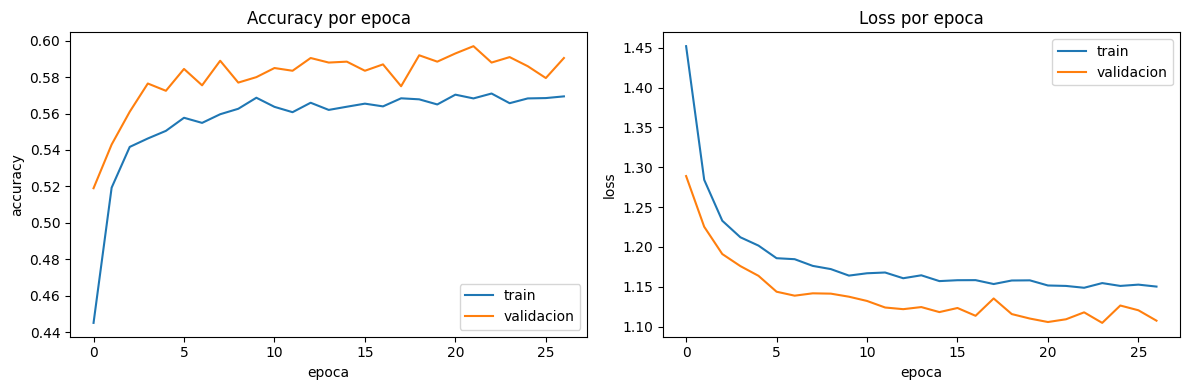

In [17]:
import matplotlib.pyplot as plt

hist = historia.history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(hist["accuracy"], label="train")
ax1.plot(hist["val_accuracy"], label="validacion")
ax1.set_title("Accuracy por epoca")
ax1.set_xlabel("epoca"); ax1.set_ylabel("accuracy"); ax1.legend()
ax2.plot(hist["loss"], label="train")
ax2.plot(hist["val_loss"], label="validacion")
ax2.set_title("Loss por epoca")
ax2.set_xlabel("epoca"); ax2.set_ylabel("loss"); ax2.legend()
plt.tight_layout()
plt.show()

Ahora evalúo sobre test: primero el resultado global, luego el informe por clase (precision, recall y f1 de cada emoción) y la matriz de confusión, que me dice qué emociones se confunden entre sí.

Test  ->  loss: 1.1016 | accuracy: 0.5905

Informe de clasificacion por clase:
              precision    recall  f1-score   support

     sadness      0.570     0.714     0.634       581
         joy      0.618     0.839     0.711       695
        love      0.362     0.107     0.165       159
       anger      0.592     0.338     0.431       275
        fear      0.585     0.277     0.376       224
    surprise      0.611     0.167     0.262        66

    accuracy                          0.591      2000
   macro avg      0.556     0.407     0.430      2000
weighted avg      0.576     0.591     0.554      2000



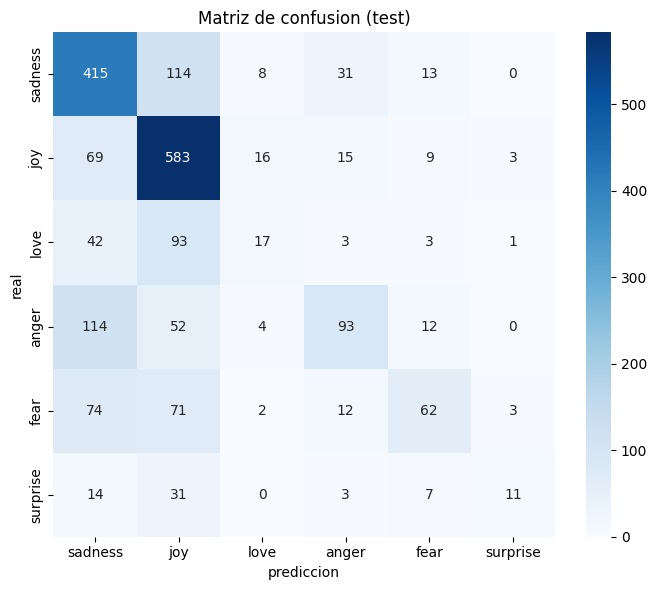

In [18]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Resultado global sobre test.
loss_test, acc_test = cabeza.evaluate(cls_test, y_test, verbose=0)
print(f"Test  ->  loss: {loss_test:.4f} | accuracy: {acc_test:.4f}")
print()

# Predicciones y metricas por clase.
probas = cabeza.predict(cls_test, verbose=0)
y_pred = probas.argmax(axis=1)
print("Informe de clasificacion por clase:")
print(classification_report(y_test, y_pred, target_names=nombres_clases, digits=3))

# Matriz de confusion.
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=nombres_clases, yticklabels=nombres_clases)
plt.title("Matriz de confusion (test)")
plt.xlabel("prediccion"); plt.ylabel("real")
plt.tight_layout()
plt.show()

#### Qué saco de la Tarea 6

- **Accuracy en test: 0.59.** Para ponerlo en contexto, un modelo que predijera siempre la clase mayoritaria (joy) acertaría ~0.35; así que el modelo ha aprendido algo de verdad, pero se queda lejos de un buen clasificador.
- **Las curvas** de train y validación van muy juntas y se estancan pronto: confirma el infraajuste (no es que sobreajuste, es que no da más de sí con estos embeddings).
- **Por clase** hay un patrón muy revelador en la matriz de confusión. Acierta bien en las dos clases grandes, `joy` (f1 0.71) y `sadness` (f1 0.63), pero las demás se "caen" hacia ellas:
  - `love` y `surprise` se confunden sobre todo con `joy` (de los 159 ejemplos de `love`, predice 93 como `joy` y solo 17 bien).
  - `anger` y `fear` se confunden sobre todo con `sadness`.
- Es decir, el modelo aprende básicamente una separación gruesa entre emociones "positivas" (alrededor de joy) y "negativas" (alrededor de sadness), pero no distingue las finas. Encaja con lo que vi en el EDA: las clases minoritarias tienen pocos ejemplos y se solapan con las mayoritarias.

## ✨ Tarea 7: Reflexión final

* Si has llegado hasta aquí: Enhorabuena!!!. Recuerda explicar todo lo que ha ido pasando por el camino.  

* Si no, describe en detalle hasta donde has llegado y qué está haciendo que no hayas conseguido completar el entregable. Y sobretodo ...., cómo lo vas a arreglar para que cuando te encarguen una tarea real se este tipo, la superes con éxito.

In [19]:
# Tu explicación aquí

#### Reflexión final

**¿Lo he conseguido?** A medias, y creo que ahí está lo interesante. He montado de principio a fin un clasificador de emociones con BERT: elegí el problema y el dataset, lo exploré, lo dividí, construí el modelo encadenando tokenizador + `TFBertModel` + cabeza sobre el `[CLS]`, lo entrené y lo evalué. Funciona y da un 59% de accuracy. No es un gran número, pero entiendo perfectamente por qué, y para mí ese ha sido el verdadero aprendizaje.

**Las decisiones que tomé y por qué**

- Elegí el dataset `emotion` por ser un problema realista, en inglés (compatible con `bert-base-uncased`, el de clase), con textos cortos (manejable en CPU) y con clases desbalanceadas que daban juego para analizar.
- Decidí **congelar BERT** y usarlo solo como extractor de características, entrenando una cabeza encima. Lo hice porque no tengo GPU y reentrenar 110 millones de parámetros en CPU es inviable. Como BERT estaba congelado, calculé los embeddings `[CLS]` una sola vez y los guardé en disco, con lo que entrenar la cabeza pasó a ser cuestión de segundos.

**Lo que más me costó (dificultades reales)**

- **El entorno fue una batalla.** Al instalar `transformers` y `datasets`, pip me actualizó NumPy a la versión 2 y rompió TensorFlow (estaba compilado contra NumPy 1). Acabé creando un entorno virtual aislado con versiones fijadas. Dentro me encontré dos sorpresas más: `aiohttp` reciente no funciona en Python 3.9.0 (un bug de `typing`), y `transformers` 4.57 tiene su soporte de TensorFlow deprecado, así que al cargar BERT intentaba convertir pesos de PyTorch y fallaba; lo arreglé forzando los pesos nativos de TF con `use_safetensors=False`. Además `tf.keras` daba un error de carga, que esquivé usando el paquete `keras` directamente.
- **Cálculo lento y un susto.** Calcular los embeddings de los 20.000 textos en CPU son ~25 minutos. Lo dejé en segundo plano y, a mitad, el portátil se suspendió y el proceso se quedó parado. Por suerte lo había hecho reentrante (guardaba por trozos), así que al relanzarlo continuó desde donde iba en lugar de empezar de cero. Lección: para procesos largos, guardar el progreso de forma incremental no es opcional.

**El aprendizaje técnico más importante**

El modelo se queda en 59% y descubrí que no es por la cabeza (probé una más grande y pesos por clase, sin mejora) ni por los hiperparámetros, sino por los **embeddings**. El vector `[CLS]` de un BERT **sin fine-tuning** es un resumen de frase bastante pobre: sirve para separar a grandes rasgos emociones positivas (joy) de negativas (sadness), pero no para distinguir las finas (love, surprise...), que se "caen" hacia las mayoritarias. Esto me dejó clara una idea que había oído en teoría pero ahora he tocado con las manos: el `[CLS]` preentrenado no es mágico; cobra sentido cuando se afina a la tarea concreta.

**Cómo lo arreglaría / qué haría distinto**

- El paso natural para subir de 59% a ~90% es **descongelar BERT y hacer fine-tuning** de toda la red, lo que requiere una GPU (lo haría en Colab). El pipeline que ya tengo me vale casi tal cual: cambiaría `trainable = True`, usaría un learning rate mucho más pequeño (~2e-5) y entrenaría sobre los textos en vez de sobre los embeddings cacheados.
- Sin llegar al fine-tuning, probaría a usar el **promedio de todos los tokens** (mean pooling) en lugar del `[CLS]`, que suele dar mejores representaciones con BERT congelado, o directamente un modelo ya afinado para frases (tipo sentence-transformers).
- Para el desbalanceo, además de pesos por clase, fijaría como objetivo una métrica centrada en las minoritarias (macro-F1) y no solo la accuracy.

**Lo que me llevo en la mochila.** Más que el número final, me llevo haber montado todo el flujo desde cero y haber peleado con los problemas reales (entornos, versiones, cómputo, un proceso que se cae) que no aparecen cuando te dan el notebook ya hecho. Y sobre todo, entender *por qué* mi modelo se queda corto y saber exactamente qué haría para mejorarlo. Como decía Yoda, del fracaso (aquí parcial) se aprende más que del éxito fácil.